# Introduction
**1.background**

U.S. Treausury securities are widely used as benchmarks in fixed-income markets. Treasury yields vary across maturities, and changes in the yield curve can provide information about interest-rate conditions, market expectations, and changes in the macroeconomic environment.

This project analyzes daily U.S. Treasury constant-maturity yields from 2015-01-01 to 2026-09-01 across selected maturities. The analysis focuese on yield trends, yield-curve shape, maturity correlations, daily yield volatility, and extreme daily movements.

**2.Business Question**

2.1 From a fixed-income trading and operations perspective:\
2.2 How have U.S. Treasury yields and the yield curve changed over time?\
2.3 Which maturities tend to experience larger day-to-day yield movements?\
2.4 When unusually large yield changes occur, are they concentrated in one maturity or visible across the curve?

**3.Research Question**

3.1 How did Treasury yields evolve across different maturities between 2015 and 2026?\
3.2 When did the yield curve become steep, flat, or inverted?\
3.3 How strongly do yields across maturities move together?\
3.4 Which maturities show the highest daily yield volatility?\
3.5 What were the most extreme daily yield movements in the sample, and what market events coincided with them?

In [1]:
import pandas as pd

In [2]:
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# 1. Load and Examine data
The dataset is based on the Federal Reserve's H.15 historical interest-rate data. The raw file contains metadata rows and daily observations for U.S. Treasury constant-maturity yields.

In [3]:
us_treasurySecur_data = pd.read_csv('E:/py_learning/U.S._Treasury_Data/FRB_H15.csv')

In [4]:
us_treasurySecur_data.shape

(16887, 12)

In [5]:
us_treasurySecur_data.head()

,Series Description,"Market yield on U.S. Treasury securities at 1-month constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 3-month constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 6-month constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 1-year constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 2-year constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 3-year constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 5-year constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 7-year constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 10-year constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 20-year constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 30-year constant maturity, quoted on investment basis"
0,Unit:,Percent:_Per_Year,Percent:_Per_Year,Percent:_Per_Year,Percent:_Per_Year,Percent:_Per_Year,Percent:_Per_Year,Percent:_Per_Year,Percent:_Per_Year,Percent:_Per_Year,Percent:_Per_Year,Percent:_Per_Year
1,Multiplier:,1,1,1,1,1,1,1,1,1,1,1
2,Currency:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Unique Identifier:,H15/H15/RIFLGFCM01_N.B,H15/H15/RIFLGFCM03_N.B,H15/H15/RIFLGFCM06_N.B,H15/H15/RIFLGFCY01_N.B,H15/H15/RIFLGFCY02_N.B,H15/H15/RIFLGFCY03_N.B,H15/H15/RIFLGFCY05_N.B,H15/H15/RIFLGFCY07_N.B,H15/H15/RIFLGFCY10_N.B,H15/H15/RIFLGFCY20_N.B,H15/H15/RIFLGFCY30_N.B
4,Time Period,RIFLGFCM01_N.B,RIFLGFCM03_N.B,RIFLGFCM06_N.B,RIFLGFCY01_N.B,RIFLGFCY02_N.B,RIFLGFCY03_N.B,RIFLGFCY05_N.B,RIFLGFCY07_N.B,RIFLGFCY10_N.B,RIFLGFCY20_N.B,RIFLGFCY30_N.B


In [6]:
us_treasurySecur_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16887 entries, 0 to 16886
Data columns (total 12 columns):
 #   Column                                                                                              Non-Null Count  Dtype 
---  ------                                                                                              --------------  ----- 
 0   Series Description                                                                                  16887 non-null  object
 1   Market yield on U.S. Treasury securities at 1-month  constant maturity, quoted on investment basis  6561 non-null   object
 2   Market yield on U.S. Treasury securities at 3-month  constant maturity, quoted on investment basis  11756 non-null  object
 3   Market yield on U.S. Treasury securities at 6-month  constant maturity, quoted on investment basis  11756 non-null  object
 4   Market yield on U.S. Treasury securities at 1-year  constant maturity, quoted on investment basis   16886 non-null  ob

In [7]:
us_treasurySecur_data['Series Description'].unique()

array(['Unit:', 'Multiplier:', 'Currency:', ..., '2026-09-14',
       '2026-09-15', '2026-09-16'], dtype=object)

In [8]:
us_treasurySecur_data.tail()

,Series Description,"Market yield on U.S. Treasury securities at 1-month constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 3-month constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 6-month constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 1-year constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 2-year constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 3-year constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 5-year constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 7-year constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 10-year constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 20-year constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 30-year constant maturity, quoted on investment basis"
16882,2026-09-10,3.91,4.00,4.07,4.28,4.56,4.63,4.75,4.84,4.95,5.39,5.37
16883,2026-09-11,3.93,4.07,4.12,4.35,4.63,4.69,4.78,4.87,4.96,5.38,5.35
16884,2026-09-14,3.94,4.11,4.18,4.37,4.65,4.73,4.80,4.88,4.97,5.37,5.34
16885,2026-09-15,3.93,4.11,4.17,4.39,4.67,4.76,4.83,4.91,5.00,5.40,5.36
16886,2026-09-16,3.96,4.14,4.22,4.45,4.74,4.82,4.86,4.94,5.01,5.39,5.35


# 2. Data cleaning

In [ ]:
# rename the columns

In [9]:
us_treasurySecur_data.columns=['Date','1M','3M','6M','1Y','2Y','3Y','5Y','7Y','10Y','20Y','30Y']

In [ ]:
# drop the unnecessary data

In [10]:
us_treasurySecur_data.drop([0,1,2,3,4],inplace=True,axis=0)

In [11]:
us_treasurySecur_data.drop('1M',inplace=True,axis=1)

In [12]:
us_treasurySecur_data.head()

,Date,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
5,1962-01-02,NaN,NaN,3.22,NaN,3.70,3.88,NaN,4.06,4.07,NaN
6,1962-01-03,NaN,NaN,3.24,NaN,3.70,3.87,NaN,4.03,4.07,NaN
7,1962-01-04,NaN,NaN,3.24,NaN,3.69,3.86,NaN,3.99,4.06,NaN
8,1962-01-05,NaN,NaN,3.26,NaN,3.71,3.89,NaN,4.02,4.07,NaN
9,1962-01-08,NaN,NaN,3.31,NaN,3.71,3.91,NaN,4.03,4.08,NaN


In [ ]:
# selected the 'Date' from 2015-01-01 to 2026-09-01 and set 'Date' as index

In [13]:
us_treasurySecur_data['Date']=pd.to_datetime(us_treasurySecur_data['Date'])

In [14]:
us_treasurySecur_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16882 entries, 5 to 16886
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    16882 non-null  datetime64[ns]
 1   3M      11752 non-null  object        
 2   6M      11752 non-null  object        
 3   1Y      16882 non-null  object        
 4   2Y      13122 non-null  object        
 5   3Y      16882 non-null  object        
 6   5Y      16882 non-null  object        
 7   7Y      14927 non-null  object        
 8   10Y     16882 non-null  object        
 9   20Y     16882 non-null  object        
 10  30Y     12937 non-null  object        
dtypes: datetime64[ns](1), object(10)
memory usage: 1.4+ MB


In [15]:
us_treasurySecur_data=us_treasurySecur_data.sort_values(by='Date')

In [154]:
us_treasurySecur_timeselected = us_treasurySecur_data[(us_treasurySecur_data['Date'] >= '2015-01-01')
                                &(us_treasurySecur_data['Date'] <='2026-09-01')]

In [17]:
us_treasurySecur_timeselected.shape

(3044, 11)

In [18]:
us_treasurySecur_timeselected.reset_index( drop = True)

,Date,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
0,2015-01-01,ND,ND,ND,ND,ND,ND,ND,ND,ND,ND
1,2015-01-02,0.02,0.11,0.25,0.66,1.07,1.61,1.92,2.12,2.41,2.69
2,2015-01-05,0.03,0.10,0.26,0.68,1.06,1.57,1.85,2.04,2.32,2.60
3,2015-01-06,0.03,0.10,0.25,0.65,1.02,1.50,1.78,1.97,2.25,2.52
4,2015-01-07,0.03,0.09,0.25,0.62,1.00,1.47,1.76,1.96,2.25,2.52
...,...,...,...,...,...,...,...,...,...,...,...
3039,2026-08-26,3.85,3.94,4.02,4.19,4.29,4.37,4.51,4.66,5.17,5.18
3040,2026-08-27,3.84,3.94,4.04,4.20,4.30,4.38,4.52,4.67,5.18,5.19
3041,2026-08-28,3.90,4.02,4.15,4.34,4.41,4.48,4.59,4.73,5.21,5.22
3042,2026-08-31,3.91,3.99,4.16,4.34,4.40,4.49,4.62,4.75,5.24,5.25


In [19]:
us_treasurySecur_timeselected=us_treasurySecur_timeselected.set_index('Date')

In [20]:
us_treasurySecur_timeselected.head()

,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
Date,,,,,,,,,,
2015-01-01,ND,ND,ND,ND,ND,ND,ND,ND,ND,ND
2015-01-02,0.02,0.11,0.25,0.66,1.07,1.61,1.92,2.12,2.41,2.69
2015-01-05,0.03,0.10,0.26,0.68,1.06,1.57,1.85,2.04,2.32,2.60
2015-01-06,0.03,0.10,0.25,0.65,1.02,1.50,1.78,1.97,2.25,2.52
2015-01-07,0.03,0.09,0.25,0.62,1.00,1.47,1.76,1.96,2.25,2.52


In [ ]:
# check duplicates

In [21]:
us_treasurySecur_timeselected[us_treasurySecur_timeselected.duplicated(keep=False)== True]

,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
Date,,,,,,,,,,
2015-01-01,ND,ND,ND,ND,ND,ND,ND,ND,ND,ND
2015-01-19,ND,ND,ND,ND,ND,ND,ND,ND,ND,ND
2015-02-16,ND,ND,ND,ND,ND,ND,ND,ND,ND,ND
2015-05-25,ND,ND,ND,ND,ND,ND,ND,ND,ND,ND
2015-07-03,ND,ND,ND,ND,ND,ND,ND,ND,ND,ND
...,...,...,...,...,...,...,...,...,...,...
2026-01-19,ND,ND,ND,ND,ND,ND,ND,ND,ND,ND
2026-02-16,ND,ND,ND,ND,ND,ND,ND,ND,ND,ND
2026-05-25,ND,ND,ND,ND,ND,ND,ND,ND,ND,ND


In [ ]:
# There are 126 rows of ND data, which means 'no data',so drop them.

In [23]:
us_treasurySecur_timeselected_cleaned = us_treasurySecur_timeselected.drop_duplicates(keep=False)

In [24]:
us_treasurySecur_timeselected_cleaned.duplicated().sum()

0

In [ ]:
# check NaN

In [25]:
us_treasurySecur_timeselected_cleaned.isnull().sum()

3M     0
6M     0
1Y     0
2Y     0
3Y     0
5Y     0
7Y     0
10Y    0
20Y    0
30Y    0
dtype: int64

In [ ]:
# Convert the object to float

In [26]:
us_treasurySecur_timeselected_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2918 entries, 2015-01-02 to 2026-09-01
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   3M      2918 non-null   object
 1   6M      2918 non-null   object
 2   1Y      2918 non-null   object
 3   2Y      2918 non-null   object
 4   3Y      2918 non-null   object
 5   5Y      2918 non-null   object
 6   7Y      2918 non-null   object
 7   10Y     2918 non-null   object
 8   20Y     2918 non-null   object
 9   30Y     2918 non-null   object
dtypes: object(10)
memory usage: 250.8+ KB


In [27]:
us_treasurySecur_timeselected_cleaned = us_treasurySecur_timeselected_cleaned.astype(float)

In [ ]:
# Check  values

In [28]:
us_treasurySecur_timeselected_cleaned.describe()

,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
count,2918.000000,2918.000000,2918.000000,2918.000000,2918.000000,2918.000000,2918.000000,2918.000000,2918.000000,2918.000000
mean,2.145932,2.209291,2.225744,2.262461,2.316974,2.456148,2.621354,2.744853,3.110857,3.199239
std,1.964090,1.904434,1.783594,1.594942,1.470061,1.311759,1.225791,1.173306,1.160142,1.050078
min,0.000000,0.020000,0.040000,0.090000,0.100000,0.190000,0.360000,0.520000,0.870000,0.990000
25%,0.220000,0.380000,0.510000,0.740000,1.000000,1.400000,1.660000,1.810000,2.200000,2.430000
50%,1.660000,1.835000,1.910000,1.980000,2.080000,2.200000,2.360000,2.485000,2.790000,3.000000
75%,4.037500,4.020000,3.980000,3.880000,3.800000,3.780000,3.900000,3.990000,4.320000,4.170000
max,5.630000,5.610000,5.490000,5.190000,5.030000,4.950000,5.000000,4.980000,5.300000,5.310000


In [152]:
# The minimum value of 0 can be observed in '3M', so let's move on to checking how many zeros in '3M"
(us_treasurySecur_timeselected_cleaned['3M']==0).sum()

13

In [ ]:
# Check when the values were zero

In [86]:
us_treasurySecur_timeselected_cleaned[us_treasurySecur_timeselected_cleaned['3M']==0.0]['3M']

Date
2015-09-18    0.0
2015-09-22    0.0
2015-09-25    0.0
2015-09-30    0.0
2015-10-01    0.0
2015-10-02    0.0
2015-10-06    0.0
2015-10-07    0.0
2015-10-08    0.0
2015-10-14    0.0
2015-10-22    0.0
2020-03-25    0.0
2020-03-26    0.0
Name: 3M, dtype: float64

In [ ]:
# Check the dates before and after the value hits zero 

In [87]:
us_treasurySecur_timeselected_cleaned.loc['2015-09-15':'2015-10-25','3M']

Date
2015-09-15    0.07
2015-09-16    0.06
2015-09-17    0.01
2015-09-18    0.00
2015-09-21    0.01
2015-09-22    0.00
2015-09-23    0.01
2015-09-24    0.01
2015-09-25    0.00
2015-09-28    0.01
2015-09-29    0.01
2015-09-30    0.00
2015-10-01    0.00
2015-10-02    0.00
2015-10-05    0.01
2015-10-06    0.00
2015-10-07    0.00
2015-10-08    0.00
2015-10-09    0.01
2015-10-13    0.01
2015-10-14    0.00
2015-10-15    0.01
2015-10-16    0.01
2015-10-19    0.02
2015-10-20    0.02
2015-10-21    0.01
2015-10-22    0.00
2015-10-23    0.01
Name: 3M, dtype: float64

In [88]:
us_treasurySecur_timeselected_cleaned.loc['2020-03-20':'2020-03-30','3M']

Date
2020-03-20    0.05
2020-03-23    0.02
2020-03-24    0.01
2020-03-25    0.00
2020-03-26    0.00
2020-03-27    0.03
2020-03-30    0.12
Name: 3M, dtype: float64

The '3M' Treasury contains 13 observations recorded as 0.00%. Since the source data are reported
to two decimal places and neighbouring observations are as low as 0.01, these zero values may reflect
rounding of very low yields rather than missing observations. therefore, the original values are retained

In [29]:
us_treasurySecur_timeselected_cleaned.head()

,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
Date,,,,,,,,,,
2015-01-02,0.02,0.11,0.25,0.66,1.07,1.61,1.92,2.12,2.41,2.69
2015-01-05,0.03,0.10,0.26,0.68,1.06,1.57,1.85,2.04,2.32,2.60
2015-01-06,0.03,0.10,0.25,0.65,1.02,1.50,1.78,1.97,2.25,2.52
2015-01-07,0.03,0.09,0.25,0.62,1.00,1.47,1.76,1.96,2.25,2.52
2015-01-08,0.03,0.08,0.23,0.62,1.00,1.50,1.81,2.03,2.33,2.59


In [30]:
us_treasurySecur_timeselected_cleaned.dtypes

3M     float64
6M     float64
1Y     float64
2Y     float64
3Y     float64
5Y     float64
7Y     float64
10Y    float64
20Y    float64
30Y    float64
dtype: object

# 3. Exploratory Data Analysis

## 3.1 overall yield trends

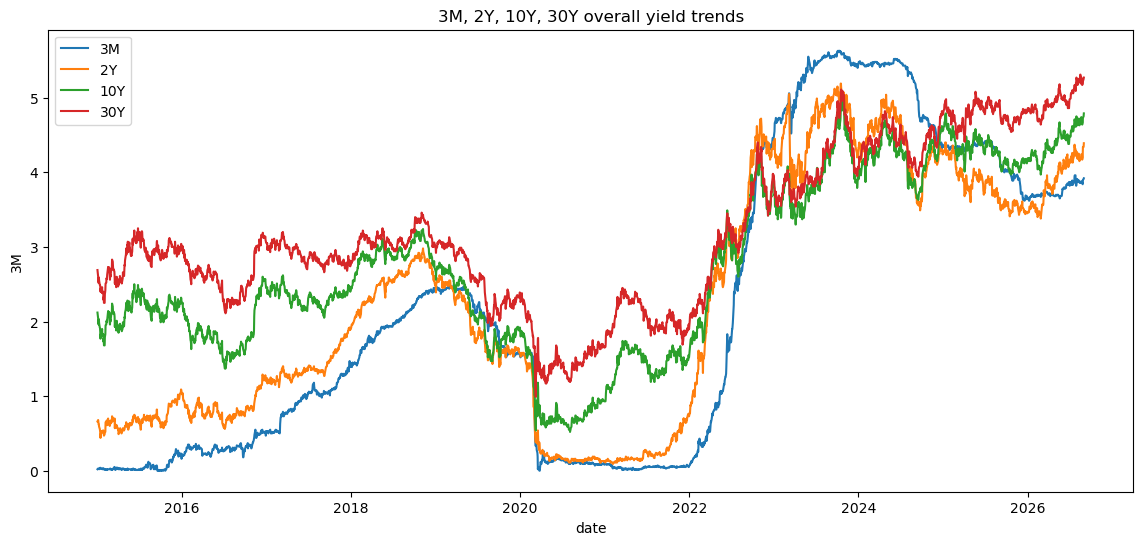

In [31]:
plt.figure(figsize=(14,6))

plt.title('3M, 2Y, 10Y, 30Y overall yield trends')
sns.lineplot(data=us_treasurySecur_timeselected_cleaned['3M'],label='3M')
sns.lineplot(data=us_treasurySecur_timeselected_cleaned['2Y'],label='2Y')
sns.lineplot(data=us_treasurySecur_timeselected_cleaned['10Y'],label='10Y')
sns.lineplot(data=us_treasurySecur_timeselected_cleaned['30Y'],label='30Y')
plt.xlabel('date')
plt.show()

As seen in the line graph, the long-term trend shows several distinct rate environments rather than a simple one-directional increase. Treasury yields increased from 2015 to 2019 at moderate level before the COVID shick, fell sharply in early 2020, and then rose again during the 2022 tightening cycle.
By 2026, yields remained above the very low levels observed in 2022-2021.

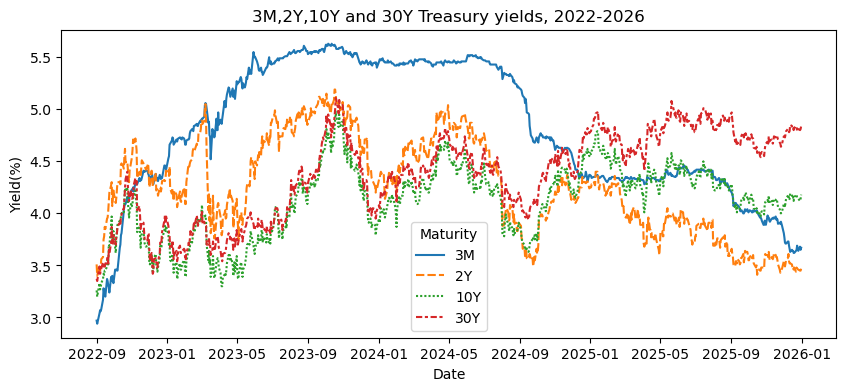

In [159]:
plt.figure(figsize=(10,4))
plt.title('3M,2Y,10Y and 30Y Treasury yields, 2022-2026')
sns.lineplot(data=us_treasurySecur_timeselected_cleaned[['3M','2Y','10Y','30Y']]['2022-09-01':'2026-01-01'])
plt.ylabel('Yield(%)')
plt.show()

Inspect the period from mid-2022 to mid-2024 , the 3M short-term Treasury yield is higher than long-term Treasury yields, such as the 10Y and 30Y , over this period.\
During this period, the yield curve became inverted, this is typically seen by the market as an warning signal of a recession historically, an inversion has often been followed by an economic slowdown. T his will be discussed in more detail at specific dates in the following section.

## 3.2 Yield Distribution

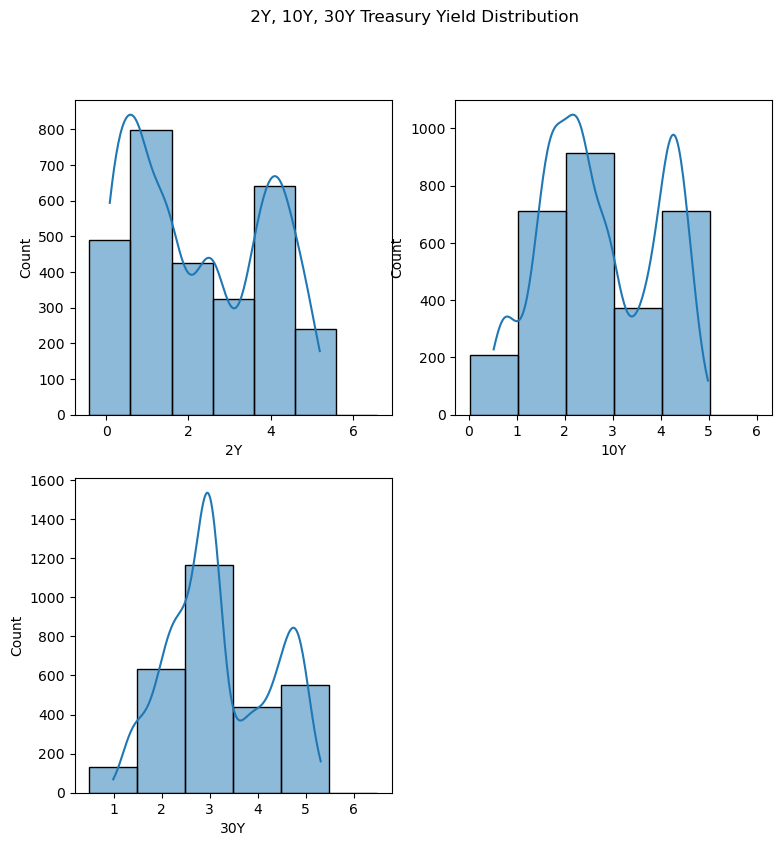

In [32]:
plt.figure(figsize=(9,9))
plt.tight_layout()
plt.subplot(2,2,1)
sns.histplot( data =us_treasurySecur_timeselected_cleaned, x='2Y', kde = True,discrete=True ) 
plt.subplot(2,2,2)
sns.histplot( data =us_treasurySecur_timeselected_cleaned, x='10Y', kde = True,discrete=True ) 
plt.subplot(2,2,3)
sns.histplot( data =us_treasurySecur_timeselected_cleaned, x='30Y', kde = True,discrete=True ) 
plt.suptitle(' 2Y, 10Y, 30Y Treasury Yield Distribution')
plt.show()

As shown in the graphs above, the distributions differ across maturities. The 2Y Treasury yields cluster mainly in 1-2% range and around 4%, higher-yield levels reached during 2022-2026 period. The 10Y yields is in the 2-3% range and 30Y yields is around 3% , their distributions are centered at higher levels on average, but their ranges also reflect major changes in the interest-rate environment over the sample.

The sample spans several distinct rate regimes, these histograms represent a mixture of market environments rather than a single stable distribution.

## 3.3 Correlation Across Maturities

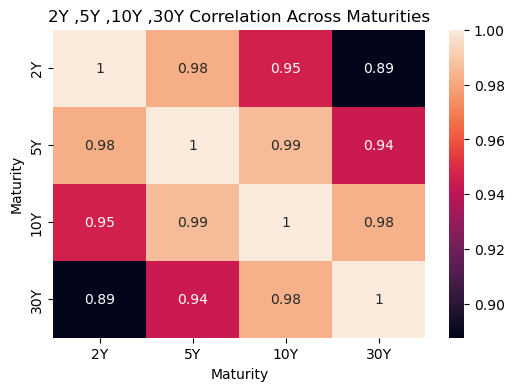

In [148]:
us_treasurySecur_timeselected_cleaned_y = us_treasurySecur_timeselected_cleaned[['2Y','5Y','10Y','30Y']]
plt.figure(figsize=(6,4))
sns.heatmap(us_treasurySecur_timeselected_cleaned_y.corr(),annot=True)
plt.title('2Y ,5Y ,10Y ,30Y Correlation Across Maturities')
plt.show()

The correlation heatmap shows that yields across different maturities are generally highly positively correlated, indicating that they tend to move together. Yields with similar maturities tend to be more highly correlated.\
The correlations are not identical, however. Differences in correlation across maturities suggest that movements in the Treasury curve are not simple parallel shifts.The relative movement between maturities can change the slope and shape of the curve.

# 4. Yield Curve Analysis

## 4.1 2022-12-30 Yield Curve

In [34]:
selectedtime_yieldCurve = us_treasurySecur_timeselected_cleaned.loc['2022-12-30']

In [35]:
selectedtime_yieldCurve=pd.DataFrame(selectedtime_yieldCurve)

In [36]:
selectedtime_yieldCurve.columns=['Yield']

In [37]:
selectedtime_yieldCurve.index.name='Maturity'

In [38]:
selectedtime_yieldCurve

,Yield
Maturity,
3M,4.42
6M,4.76
1Y,4.73
2Y,4.41
3Y,4.22
5Y,3.99
7Y,3.96
10Y,3.88
20Y,4.14


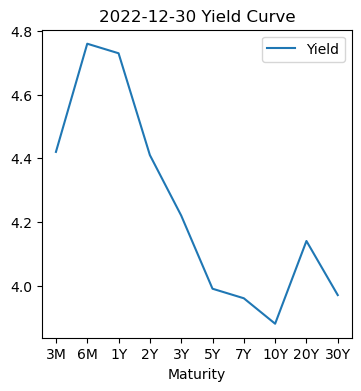

In [39]:
plt.figure(figsize=(4,4))
plt.title('2022-12-30 Yield Curve')
sns.lineplot(data=selectedtime_yieldCurve)
plt.xlabel('Maturity')
plt.show()

As mentioned eariler, the yield curve was inverted from mid-2022 to mid-2024.

The line graph based on data from 2022-12-30 clearly illustrates this inversion, with short-term yields exceeding long-term yields. For example, the 3M yield was 4.42%, compared with 3.88% for the 10Y yield. The curve reflects the market's pricing of short-term and long-term interest rates at that point in time.

## 4.2 Yield Curve Across Different Dates

In [40]:
dates = ['2019-12-31','2020-03-31','2021-12-31','2022-12-30','2024-12-31','2026-09-01']
selectedtimegroup_yieldCur = us_treasurySecur_timeselected_cleaned.loc[dates]

In [41]:
selectedtimegroup_yieldCur=selectedtimegroup_yieldCur.T

In [42]:
selectedtimegroup_yieldCur

Date,2019-12-31,2020-03-31,2021-12-31,2022-12-30,2024-12-31,2026-09-01
Maturity,,,,,,
3M,1.55,0.11,0.06,4.42,4.37,3.92
6M,1.60,0.15,0.19,4.76,4.24,4.00
1Y,1.59,0.17,0.39,4.73,4.16,4.18
2Y,1.58,0.23,0.73,4.41,4.25,4.39
3Y,1.62,0.29,0.97,4.22,4.27,4.46
5Y,1.69,0.37,1.26,3.99,4.38,4.55
7Y,1.83,0.55,1.44,3.96,4.48,4.66
10Y,1.92,0.70,1.52,3.88,4.58,4.79
20Y,2.25,1.15,1.94,4.14,4.86,5.27


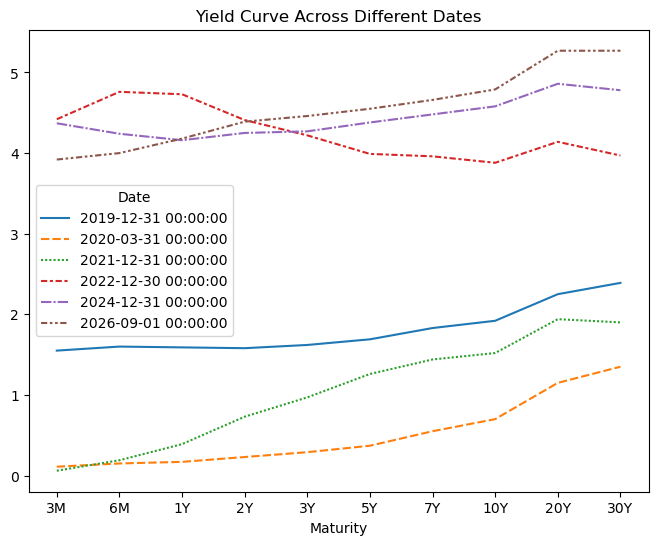

In [43]:
plt.figure(figsize=(8,6))
plt.title('Yield Curve Across Different Dates')
sns.lineplot(data=selectedtimegroup_yieldCur)
plt.show()

As the line graph shown above, we can see the shape of yield curve across different dates.The curves illustrate several distinct rate environments:\
The yield curve remained relatively low until late 2021, while higher yields were recorded after 2022.\
The yield curve on 2019-12-31 appears to be at normal levels, with longer maturities yielding more than shorter maturities.\
The yield curve on 2020-03-31 and 2021-12-31 are lower, reflecting the low-rate environment following The COVID-19 shock.\
The yield curve on 2022-12-30 is clearly inverted, with short-term yields above long-term yields.\
The yield curve on 2024-12-31 and 2026-09-01 are observed at higher levels, yields on 2026-09-01 are higher toward the long end, with the 20Y and 30Y yields at 5.27%.

## 4.3 10Y-2Y Spread

In [52]:
spread = us_treasurySecur_timeselected_cleaned[['2Y','10Y']].copy()

In [55]:
spread['10Y-2Y Spread'] =spread['10Y']-spread['2Y']

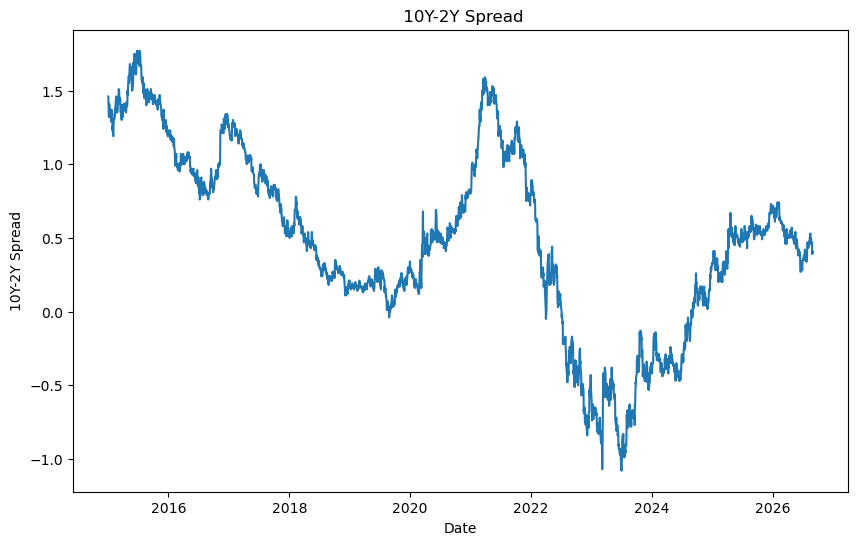

In [54]:
plt.figure(figsize=(10,6))
plt.title(' 10Y-2Y Spread')
sns.lineplot(data=spread['10Y-2Y Spread'])
plt.show()

The 10Y-2Y spread is caculated as :

        10Y yield - 2Y yield
A postive spread means the 10Y yield is above the 2Y yield, while a negative spread indicates an inverted 10Y-2Y segment.\
In this sample, the 10Y-2Y spread narrowed until mid-2020, then the spread had widened to the late 2021 due to the tightening cycle.The spread turned negative from early 2022 to early 2024, indicating the yield curve was inverted.A Recovery was observed around 2025, when the spread turned postive again.\
The spread is therefore useful for identifying changes in the slope of the intermediate-to-long portion of the Treasury curve.

## 4.4 10Y-3M Spread

In [56]:
spread['3M']=us_treasurySecur_timeselected_cleaned['3M'].copy()
spread['10Y-3M Spread']=spread['10Y']-spread['3M']

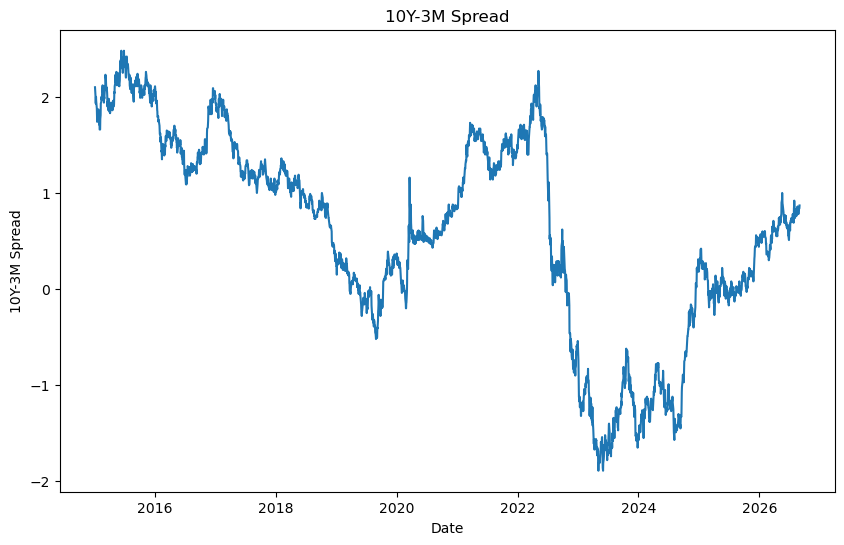

In [58]:
plt.figure(figsize=(10,6))
plt.title('10Y-3M Spread')
sns.lineplot(data=spread['10Y-3M Spread'])
plt.show()

The 10Y-3M spread compares a long-term benchmark yield with a very short-term yield:

    10Y yield - 3M yield
    
When the spread becomes negative, meaning short-term yields rise above long-term yields, the yields curve becomes inverted.\
Comparing the 10Y-2Y and 10Y-3M spreads provides a more complete view of curve inversion because the two measures capture different maturity segments.

# 5.Yield Volatility 

## 5.1 Daily changes

In [ ]:
#Daily yield changes are calculated in basis points (bp).
#Because the original yield data are expressed in percentage points, 
#  multiplying the first difference by 100 converts the change into basis points.

In [89]:
daily_yield_changes_bps = us_treasurySecur_timeselected_cleaned.copy()
daily_yield_changes_bps =daily_yield_changes_bps.diff()*100

In [115]:
daily_yield_changes_bps.describe()

Maturity,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
count,2917.000000,2917.000000,2917.000000,2917.000000,2917.000000,2917.000000,2917.000000,2917.000000,2917.000000,2917.000000
mean,0.133699,0.133356,0.134727,0.127871,0.116215,0.100788,0.093932,0.091532,0.098046,0.088447
std,2.944494,2.969156,3.984971,5.178677,5.380629,5.523313,5.552723,5.295602,5.135742,5.057867
min,-23.000000,-36.000000,-60.000000,-57.000000,-43.000000,-32.000000,-31.000000,-30.000000,-26.000000,-31.000000
25%,-1.000000,-1.000000,-1.000000,-2.000000,-2.000000,-3.000000,-3.000000,-3.000000,-3.000000,-3.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
max,34.000000,27.000000,34.000000,34.000000,35.000000,31.000000,29.000000,29.000000,35.000000,29.000000


## 5.2 Volatility Comparison

In [94]:
volatility = daily_yield_changes_bps.describe().loc['std'].to_frame()

In [95]:
volatility

,std
Maturity,
3M,2.944494
6M,2.969156
1Y,3.984971
2Y,5.178677
3Y,5.380629
5Y,5.523313
7Y,5.552723
10Y,5.295602
20Y,5.135742


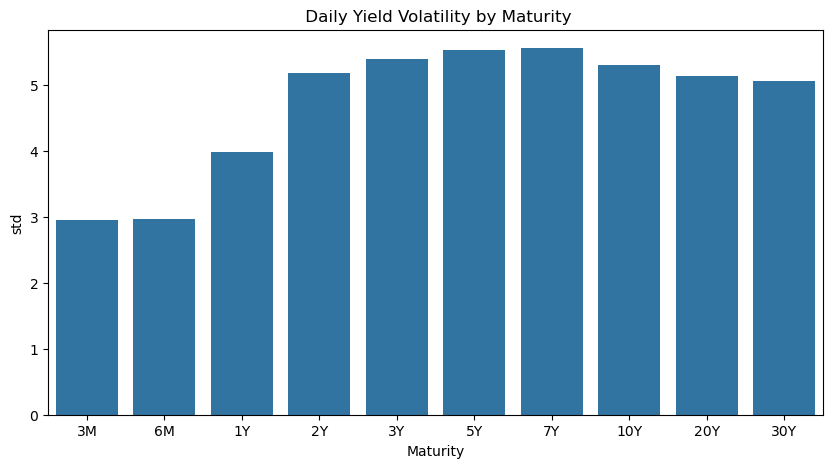

In [97]:
plt.figure(figsize=(10,5))
sns.barplot( x=volatility.index, y = volatility['std'])
plt.title(' Daily Yield Volatility by Maturity')
plt.show()

Daily yield volatility generally increases from short-term to intermediate maturities,peaks around the 7Y , and then slightly declines toward longer maturities.\
This indicates that the 7Y experienced the largest typical day-to-day yield changes among the maturities analyzed, although std measures overall dispersion and does not identify the largest individual market shock by itself.

## 5.3 Extreme Movements

In [107]:
describe_dailychanges_bps =daily_yield_changes_bps.describe().T

In [108]:
describe_dailychanges_bps.sort_values(by='max',ascending=False)

,count,mean,std,min,25%,50%,75%,max
Maturity,,,,,,,,
3Y,2917.0,0.116215,5.380629,-43.0,-2.0,0.0,3.0,35.0
20Y,2917.0,0.098046,5.135742,-26.0,-3.0,0.0,3.0,35.0
3M,2917.0,0.133699,2.944494,-23.0,-1.0,0.0,1.0,34.0
1Y,2917.0,0.134727,3.984971,-60.0,-1.0,0.0,1.0,34.0
2Y,2917.0,0.127871,5.178677,-57.0,-2.0,0.0,3.0,34.0
5Y,2917.0,0.100788,5.523313,-32.0,-3.0,0.0,3.0,31.0
10Y,2917.0,0.091532,5.295602,-30.0,-3.0,0.0,3.0,29.0
30Y,2917.0,0.088447,5.057867,-31.0,-3.0,0.0,3.0,29.0
7Y,2917.0,0.093932,5.552723,-31.0,-3.0,0.0,3.0,29.0


In [109]:
describe_dailychanges_bps.sort_values(by='min')

,count,mean,std,min,25%,50%,75%,max
Maturity,,,,,,,,
1Y,2917.0,0.134727,3.984971,-60.0,-1.0,0.0,1.0,34.0
2Y,2917.0,0.127871,5.178677,-57.0,-2.0,0.0,3.0,34.0
3Y,2917.0,0.116215,5.380629,-43.0,-2.0,0.0,3.0,35.0
6M,2917.0,0.133356,2.969156,-36.0,-1.0,0.0,1.0,27.0
5Y,2917.0,0.100788,5.523313,-32.0,-3.0,0.0,3.0,31.0
7Y,2917.0,0.093932,5.552723,-31.0,-3.0,0.0,3.0,29.0
30Y,2917.0,0.088447,5.057867,-31.0,-3.0,0.0,3.0,29.0
10Y,2917.0,0.091532,5.295602,-30.0,-3.0,0.0,3.0,29.0
20Y,2917.0,0.098046,5.135742,-26.0,-3.0,0.0,3.0,35.0


In [113]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

In [114]:
daily_yield_changes_bps['3Y'].idxmax()
daily_yield_changes_bps['20Y'].idxmax()
daily_yield_changes_bps['1Y'].idxmin()

Timestamp('2022-06-13 00:00:00')

Timestamp('2020-03-17 00:00:00')

Timestamp('2023-03-13 00:00:00')

The largest positive daily yield changes in the sample include:
    3Y : +35bp on 2022-06-13
    20Y: +35bp on 2020-03-17
The largest negative movement is:
    1Y : -60bp on 2023-03-13

The std of these maturities show that the extreme observations occured in maturities with relatively high daily variability, but an extreme observation should be analyzed separately from overall volatility.

In [144]:
InteractiveShell.ast_node_interactivity = 'last'

In [ ]:
# check the date before and after the daily yield change dramatically

In [ ]:
# 2022-06-13:  3Y +35bp

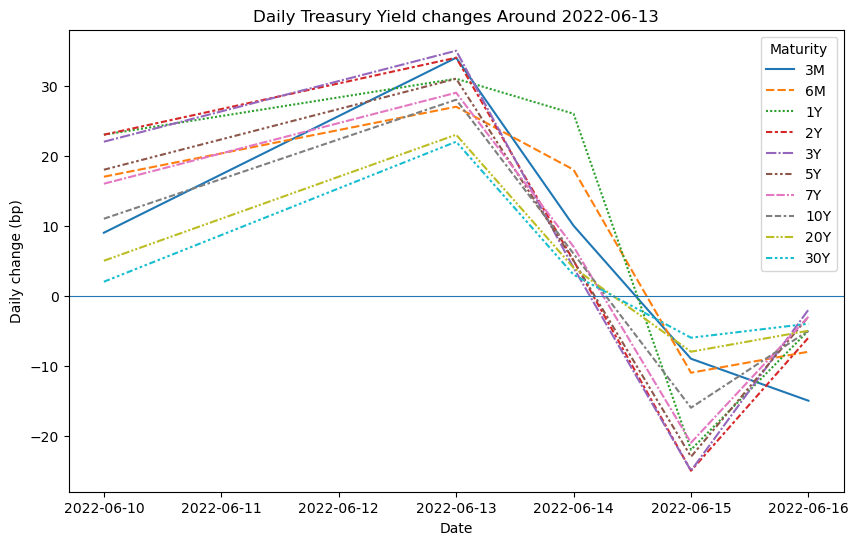

In [156]:
plt.figure(figsize=(10,6))
plt.title('Daily Treasury Yield changes Around 2022-06-13')
sns.lineplot(data = daily_yield_changes_bps.loc['2022-06-10':'2022-06-16'])
plt.ylabel('Daily change (bp)')
plt.axhline(0, linewidth=0.8)
plt.show()

In [ ]:
# 2020-03-17: 20Y +35bp

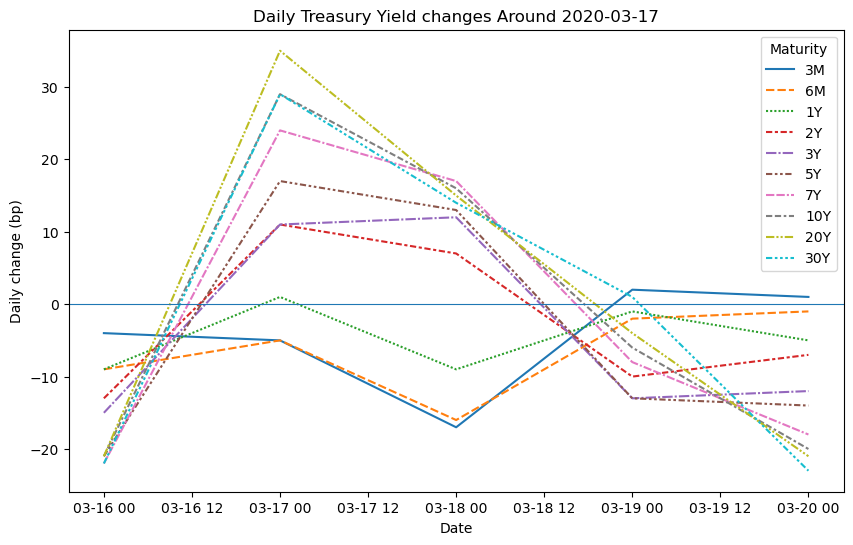

In [157]:
plt.figure(figsize=(10,6))
plt.title('Daily Treasury Yield changes Around 2020-03-17')
sns.lineplot(data = daily_yield_changes_bps.loc['2020-03-14':'2020-03-21'])
plt.ylabel('Daily change (bp)')
plt.axhline(0, linewidth=0.8)
plt.show()

In [ ]:
# 2023-03-13: 1Y -60bp

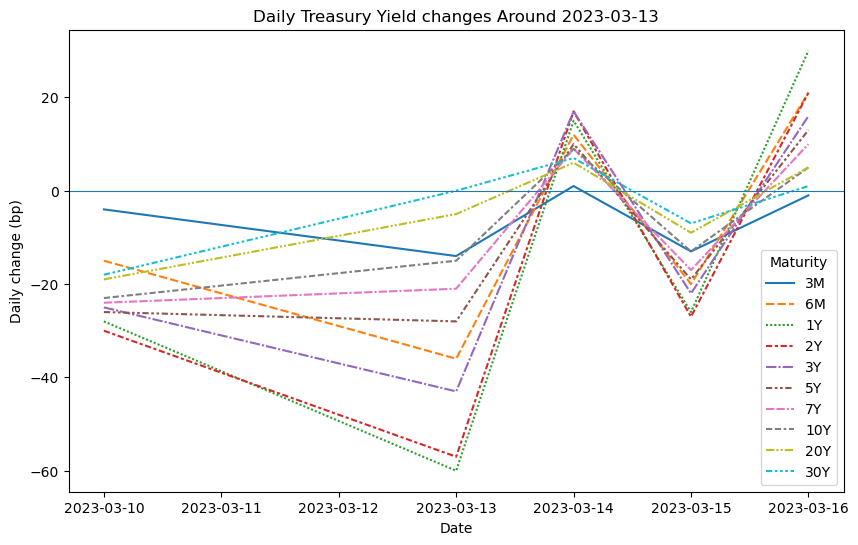

In [158]:
plt.figure(figsize=(10,6))
plt.title('Daily Treasury Yield changes Around 2023-03-13')
sns.lineplot(data = daily_yield_changes_bps.loc['2023-03-10':'2023-03-16'])
plt.ylabel('Daily change (bp)')
plt.axhline(0, linewidth=0.8)
plt.show()

The three line graphs show that extreme movements can have different cross-maturity patterns.

On 2022-06-13: yields increase broadly across maturities, consistent with a market-wide repricing of interest-rate expectations.(Source: https://www.bls.gov/news.release/archives/cpi_06102022.htm;
https://www.federalreserve.gov/monetarypolicy/2022-06-mpr-summary.htm) 

On 2020-03-17: the Treasury market was experiencing very high volatility during the COVID-19 shock and the Fed's rapid policy response.(Source: https://www.federalreserve.gov/monetarypolicy/fomcminutes20200315.htm; https://www.federalreserve.gov/monetarypolicy/2020-06-mpr-part2.htm)

On 2023-03-13: the sharp drop was concentrated in shorter maturities, consistent with a sudden repricing of the expected short-term interest rates during the U.S. banking stress.(Source: https://www.federalreserve.gov/publications/2023-may-financial-stability-report-asset-valuations.htm)

These observations illustrate why monitoring only one maturity can miss key information about the shape and breadth of a market move.

**Market context for the three extreme movements**\
The market context below provides historical context for the observed yield movements. It should not be interpreted as proof that a single event caused the daily change.

On 2022-06-13, the 3Y yield rose about 35bp in the dataset, with the move abroad across maturities.On 2022-6-10, the U.S. Bureau of Labor Statistics reported May CPI up 8.6% year over year — the largest 12-month increase since December 1981. Fed materials from June 2022 also noted elevated inflation and expectations of further tightening. These developments offer a plausible context for the broad upward repricing in Treasury yields around June 13. (BLS; Federal Reserve, June 2022.)

On 2020-03-07, the 20Y yield increased by 35bp in the dataset during the severe Treasury-market dislocation of March 2020.Fed analysis documented unusually poor liquidity, heavy selling, and a mid-March rise in long-maturity yields despite the broader decline earlier in the crisis. The Fed was also rapidly expanding repo operations and Treasury purchases to restore market functioning. (Federal Reserve, March 2020.)

On 2023-03-13, the 1Y yield fell by about 60 bp in the dataset. This occurred immediately after the failures of Silicon Valley Bank and Signature Bank. The Fed reported that Treasury yields declined sharply following the failures, particularly at shorter maturities, as uncertainty about the economic outlook and future interest rates increased. (Federal Reserve; U.S. Treasury/Federal Reserve/FDIC, March 2023.)


# 6. Key findings
    6.1 Treasury yields moved through several distinct rate regimes. Yields fell sharply in early 2020, remained historically low during the pandemic period, and rose substantially during the 2022 tightening cycle.
    6.2 The yield curve changed shape materially over time. The curve was relatively normal in 2019, sharply lower in 2020, inverted during the 2022–2024 period, and later returned to a positive slope in the longer maturities.
    6.3 Treasury maturities are strongly correlated. Most maturities tend to move together, but differences in their movements create changes in curve slope and shape.
    6.4 Intermediate maturities showed the highest daily volatility in this sample. The 7Y Treasury had the highest std of daily yield changes at approximately 5.55 bp.
    6.5 Extreme daily moves were related with different market environments. The largest positive and negative observations occurred around periods of major inflation/rate repricing, the COVID-19 market shock, and the 2023 banking-sector stress.

# 7. Business Implications
    fixed-income trading / operations perspective
    7.1 Market monitoring: Tracking multiple maturities helps capture a broad market move from a maturity-specific movement.
    **7.2 Exception monitoring:** Large daily changes can be used as a simple trigger for reviewing unusual market movements, pricing inputs, or downstream records.
    7.3 Curve awareness: Monitoring spreads such as 10Y–2Y and 10Y–3M provides a compact way to identify changes in curve slope and inversion.
    7.4 Operational risk control: During high-volatility periods, larger market moves may increase the importance of timely data validation, trade confirmation, reconciliation, and exception handling.
    7.5 Further automation: Daily yield-change thresholds could be incorporated into a monitoring workflow to flag unusual movements for manual review.
   
The analysis is descriptive and should not be interpreted as a trading signal. In a production environment, additional market and transaction-level data would be needed before using these indicators for risk or investment decisions.

# 8. Limitations & future work
    Limitations:
       *Treasury constant maturity yields are benchmark yields rather than individual bond transaction prices.
       *The analysis is descriptive rather than causal.
       *Macroeconomics variables such as inflation, Fed policy and economic growth are not explicitly modeled.
    Future work
        *Add inflation, Federal Funds Rate, and other macroeconomic indicators.
        *Compare Treasury yield movements with major economic announcements and FOMC decisions.
        *Extend the analysis from yields to bond-price sensitivity and duration.